# From confidence interval derived from $\chi^2$ to boostrap confidence interval?

In [1]:
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

## $\chi^2$
Let's start with creating a normally distributed data $\mu = 25000$ and $\sigma = 500$. This will be our population, and we are going to estimate variance using the chi-square CI formula.

In [2]:
data = np.random.normal(loc=50, scale=20, size=100_000)

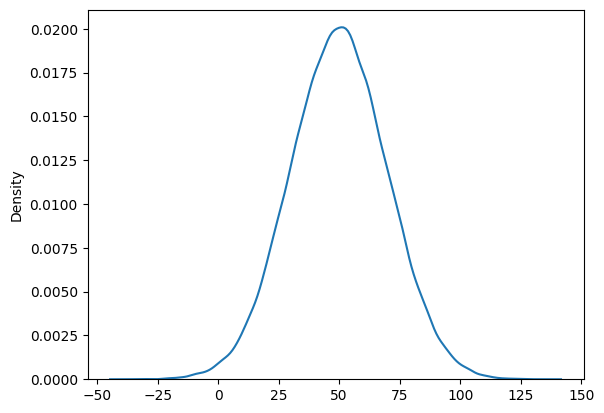

In [3]:
fig, ax = plt.subplots()
sns.kdeplot(data)
plt.show()

Yes, our data looks somewhat normal. Let's continue.

In [4]:
sample_size = 11
sample = np.random.choice(data, sample_size)
sample_variance = np.var(sample, ddof=1)
sample_variance, sqrt(sample_variance)

(np.float64(312.38413389010145), 17.674392037354536)

We are going to set our sample size as 11, so the $df$ will be 10.

So for this specific sample/sample size, we want %95 confidence. We are going to use the below formula:

$$
\frac{(n-1)s^2}{\chi_{a/2, k}^2} \lt \sigma^2 \lt \frac{(n-1)s^2}{\chi_{1-a/2, k}^2} \\
$$

$$
\frac{10s^2}{\chi_{0.025, k=10}^2} \lt \sigma^2 \lt \frac{10s^2}{\chi_{0.975, k=10}^2}
$$

In [5]:
a = 0.05
chi2_lower = stats.chi2.ppf(1 - (a / 2), sample_size - 1)
chi2_upper = stats.chi2.ppf(a / 2, sample_size - 1)

We don't directly use the chi-squared distribution, but the values we used for $\chi_{0.975}$ and $\chi_{0.025}$ comes from the two ends of this distribution.

In [6]:
chi_max = stats.chi2.ppf(0.999, sample_size - 1)
x_ticks = np.linspace(0, chi_max, 5000)
chi = stats.chi2.pdf(x_ticks, sample_size - 1)

In [7]:
x_shade = np.linspace(chi2_lower, chi2_upper, 500)
y_shade = stats.chi2.pdf(x_shade, sample_size - 1)

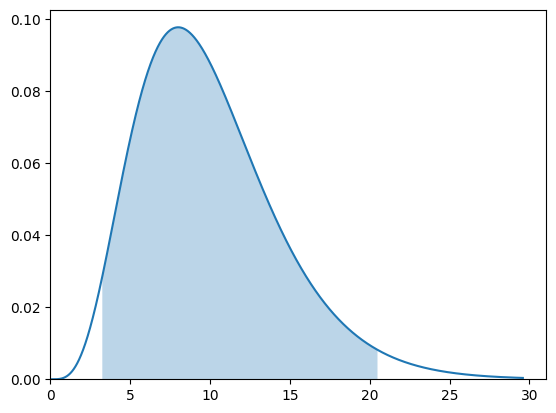

In [8]:
fig, ax = plt.subplots()
ax.plot(x_ticks, chi)
ax.fill_between(x_shade, y_shade, alpha=0.3)
ax.set_ylim(0)
ax.set_xlim(0)
plt.show()

### Result

In [9]:
highest_expected_chaos = (sample_size - 1) * sample_variance / chi2_upper
lowest_expected_chaos = (sample_size - 1) * sample_variance / chi2_lower
lowest_expected_chaos, highest_expected_chaos

(np.float64(152.50765471587746), np.float64(962.0780802089615))

Now, we can interpret this result as "Variance is in these intervals with %95 confidence", but this is not true. It actually means that, "In all the '%95 samples', %95 of the confidence intervals would contain the population variance."

## Bootstrap Confidence Interval

Chi-sqarued distribution is very useful for finding a CI for variance, when the underlying dataset is normally distributed. However, real-world data may not follow a perfectly normal distribution. In a situation like that, we can use _bootstrap confidence interval_.

In [10]:
bootstrap_variance = []
m = np.mean(data)
s = np.std(data)
sample = np.random.choice(data, 1000, replace=False)

for _ in range(5000):
    bootstrap_variance.append(
        np.var(np.random.choice(sample, len(sample), replace=True), ddof=1)
    )

Keep in mind that, when dealing with a sample, we should always use $\delta df=1$, even if we are bootstrapping (using the whole sample again).

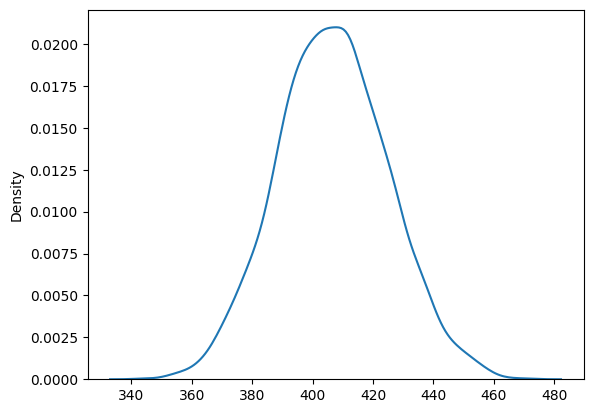

In [11]:
fig, ax = plt.subplots()
sns.kdeplot(bootstrap_variance, ax=ax)
plt.show()

In [12]:
print(f"CI for variance is: {np.quantile(bootstrap_variance, [0.025, 0.975])}")
print(f"Population variance is: {np.var(data)}")
print(
    f"Mean of the bootstrap distribution of the variance: {np.mean(bootstrap_variance)}"
)

CI for variance is: [371.45328224 443.25884831]
Population variance is: 397.2940897357729
Mean of the bootstrap distribution of the variance: 406.7326864091965
